# Crypto Perpetuals Funding: Feasibility Analysis

`config/setup.yaml` declares a cross-sectional long-short strategy on Binance perpetual futures:
which contracts trade, that decisions land on the eight-hour funding schedule, what crossing costs
and how the sample is split. This notebook asks whether the data supports it, and fits nothing.

## Learning objectives

- Count an unbalanced panel at the timestamp the strategy acts on, and read clearance of the
  fee off an exceedance curve
- Measure how long the premium a decision reads describes the same contract, and turn that
  persistence into the number of independent observations the sample holds

## Book reference

Chapter 6, Sections 6.2-6.6. Reads Binance perpetual bars and `config/setup.yaml`, never writes.

In [1]:
"""Crypto Perpetuals Funding Case Study - Feasibility Analysis."""

import re
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import yaml

from case_studies.utils.feasibility import exceedance_curve, fold_timeline, panel_acf
from data import load_crypto_perps
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, zero_line

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "crypto_perps_funding"
START_DATE = "2020-01-01"
END_DATE = "2025-12-31"
MAX_SYMBOLS = 0

## Configuration

Every knob is read from `setup.yaml`, and Sections B and D compute on the development window
alone, so nothing the holdout contains can shape a choice made here.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])
HOLDOUT_TS = pl.lit(HOLDOUT_START).str.to_datetime().dt.replace_time_zone("UTC")
PRIMARY_LABEL, LABEL_BUFFER = SETUP["labels"]["primary"], SETUP["labels"]["buffer"]
DECLARED = set(SETUP["universe"]["symbols"])
BREADTH_FLOOR = 2 * max(SETUP["backtest"]["sweep"]["top_k_grid"][PRIMARY_LABEL])
BAR_HOURS = int(SETUP["decision"]["cadence"].split("_")[0])
HORIZONS = sorted(
    int(re.search(r"(\d+)h$", name).group(1))
    for name in (PRIMARY_LABEL, *SETUP["labels"]["variants"])
    if name.startswith("fwd_ret")
)
MAKER_RT, TAKER_RT = (2 * SETUP["costs"]["fee_schedule"][k] for k in ("maker_bps", "taker_bps"))
PREMIUM = "premium_index_close"
ACF_LAGS = 21 * 24 // BAR_HOURS  # three weeks of funding periods

print(
    f"Development {START_DATE} to {HOLDOUT_START} | sealed holdout to {HOLDOUT_END}\n"
    f"{len(DECLARED)} contracts, floor {BREADTH_FLOOR} | horizons {HORIZONS} hours"
)

Development 2020-01-01 to 2024-01-01 | sealed holdout to 2025-12-31
19 contracts, floor 20 | horizons [8, 24] hours


## A. Orientation

A perpetual future has no expiry, so the venue keeps it near the index it tracks by making one
side pay the other every eight hours. The premium index is the running measure that payment is
computed from, positive while the perpetual trades above that index and negative below. That
payment is a cash flow between longs and shorts rather than a cost, and this strategy does not
collect it - it ranks contracts on their premium and holds the price move that follows. Three
questions decide whether that is worth building: are the declared contracts quoting at the funding
timestamp, is a typical move large next to the fee, and does the sample hold enough independent
observations.

## B. Universe and cost feasibility

### B.1 Load and verify the declared universe

The loader aggregates raw hourly bars onto the funding grid, so one row is one contract at one
settlement. A bar is labelled at its opening timestamp and not known until it closes a period
later, which is the clock every filter here runs on. The panel is unbalanced by listing date.

In [4]:
bars = load_crypto_perps(
    frequency=f"{BAR_HOURS}h", start_date=START_DATE, end_date=END_DATE, max_symbols=MAX_SYMBOLS
).sort(["symbol", "timestamp"])
research = bars.filter(pl.col("timestamp") + pl.duration(hours=BAR_HOURS) < HOLDOUT_TS)

loaded = set(research["symbol"].unique().to_list())
assert not loaded - DECLARED, f"in the data, undeclared in setup.yaml: {sorted(loaded - DECLARED)}"
print(
    f"{len(loaded)} of {len(DECLARED)} declared contracts, {len(research):,} funding bars, "
    f"{research['timestamp'].min().date()} to {research['timestamp'].max().date()}"
)

19 of 19 declared contracts, 66,631 funding bars, 2020-01-01 to 2023-12-31


### B.2 Breadth at every funding timestamp

One count of the universe hides what a cross-sectional book has to answer: how many contracts are
quoting when it rebalances. A sleeve of k per side needs twice k, set by the widest grid entry.

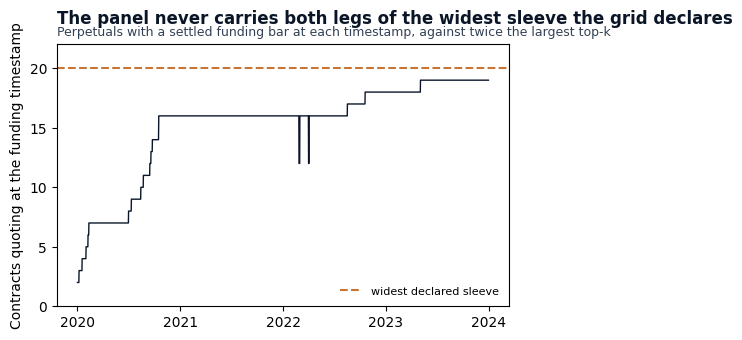

In [5]:
breadth = research.group_by("timestamp").agg(n=pl.col("symbol").n_unique()).sort("timestamp")

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(breadth["timestamp"], breadth["n"], color=COLORS["blue"], lw=1.0)
ax.axhline(BREADTH_FLOOR, color=COLORS["copper"], ls="--", lw=1.5, label="widest declared sleeve")
ax.set_ylim(0, BREADTH_FLOOR + 2)
ax.set_yticks(range(0, BREADTH_FLOOR + 3, 5))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylabel("Contracts quoting at the funding timestamp")
ax.legend(frameon=False, fontsize=8, loc="lower right")
add_message_title(
    ax,
    "The panel never carries both legs of the widest sleeve the grid declares",
    subtitle="Perpetuals with a settled funding bar at each timestamp, against twice the largest top-k",
)
plt.show()

### B.3 What a move is worth against the fee

`setup.yaml::costs.fee_schedule` charges a flat fee per trade in two tiers rather than a
per-contract spread, so cost here is a level the venue publishes rather than something this data
measures. A move counts only when the bar it ends on sits exactly one horizon ahead: four
contracts are missing settlements in 2022, and a positional shift would price a three-day move as
an eight-hour one. Both round trips are drawn against those moves at each declared horizon, on one
log axis, so the fraction clearing a tier is read off the curve.

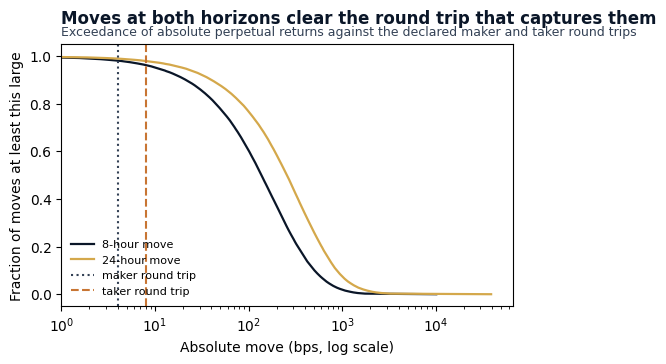

In [6]:
moves = bars
for h in HORIZONS:
    endpoint = pl.col("timestamp") + pl.duration(hours=h)
    ahead = pl.col("close").shift(-h // BAR_HOURS).over("symbol")
    on_grid = pl.col("timestamp").shift(-h // BAR_HOURS).over("symbol") == endpoint
    known = endpoint + pl.duration(hours=BAR_HOURS) < HOLDOUT_TS
    moves = moves.with_columns(
        pl.when(on_grid & known).then((ahead / pl.col("close") - 1).abs() * 1e4).alias(f"h{h}")
    )

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for h, color in zip(HORIZONS, (COLORS["blue"], COLORS["amber"]), strict=True):
    magnitude, fraction = exceedance_curve(moves[f"h{h}"].drop_nulls().to_numpy())
    ax.plot(magnitude, fraction, color=color, lw=1.6, label=f"{h}-hour move")
ax.axvline(MAKER_RT, color=COLORS["neutral"], ls=":", lw=1.5, label="maker round trip")
ax.axvline(TAKER_RT, color=COLORS["copper"], ls="--", lw=1.5, label="taker round trip")
ax.set_xscale("log")
ax.set_xlim(left=1)
ax.set_xlabel("Absolute move (bps, log scale)")
ax.set_ylabel("Fraction of moves at least this large")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(
    ax,
    "Moves at both horizons clear the round trip that captures them",
    subtitle="Exceedance of absolute perpetual returns against the declared maker and taker round trips",
)
plt.show()

### B.4 How long the premium describes the contract

Ranking contracts every funding period is only worth the turnover if what the premium says at one
settlement still describes the same contract at the next. That is an autocorrelation, computed
inside each contract: stacking the panel and correlating it measures where two contracts meet.
Lags are counted by row, so each contract contributes its longest unbroken run of settlements.

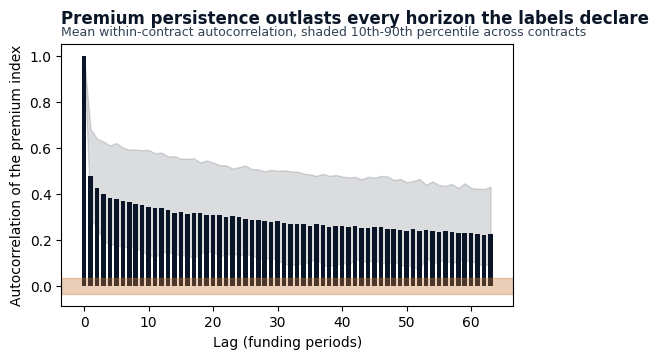

In [7]:
gap = pl.col("timestamp").diff().over("symbol").ne(pl.duration(hours=BAR_HOURS)).fill_null(True)
unbroken = (
    research.with_columns(gap.cum_sum().over("symbol").alias("run"))
    .with_columns(pl.len().over("symbol", "run").alias("run_len"))
    .filter(pl.col("run_len") == pl.col("run_len").max().over("symbol"))
)
acf = panel_acf(unbroken, entity_col="symbol", value_col=PREMIUM, max_lags=ACF_LAGS)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.fill_between(acf["lag"], acf["acf_p10"], acf["acf_p90"], color=COLORS["blue"], alpha=0.15)
ax.bar(acf["lag"], acf["acf"], color=COLORS["blue"], width=0.7)
ax.axhspan(-acf["band"][0], acf["band"][0], color=COLORS["copper"], alpha=0.35)
ax.set_xlabel("Lag (funding periods)")
ax.set_ylabel("Autocorrelation of the premium index")
add_message_title(
    ax,
    "Premium persistence outlasts every horizon the labels declare",
    subtitle="Mean within-contract autocorrelation, shaded 10th-90th percentile across contracts",
)
plt.show()

Persistence describes one contract through time. A cross-sectional book also needs contracts to
disagree at one timestamp, so quantiles are taken there and only then thinned to a daily median:
pooling three settlements first folds the level's own movement into the band a ranking reads.

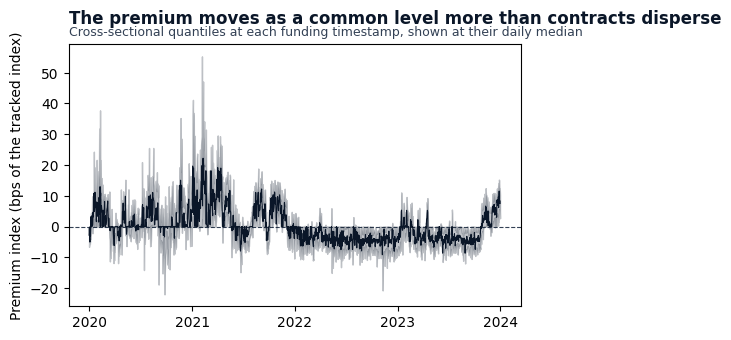

In [8]:
BANDS = (("lo", 0.1), ("mid", 0.5), ("hi", 0.9))
spread = (
    research.group_by("timestamp")
    .agg(pl.col(PREMIUM).quantile(q).mul(1e4).alias(name) for name, q in BANDS)
    .group_by(pl.col("timestamp").dt.truncate("1d").alias("day"))
    .agg(pl.col(name).median() for name, _ in BANDS)
    .sort("day")
    .drop_nulls()
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.fill_between(spread["day"], spread["lo"], spread["hi"], color=COLORS["blue"], alpha=0.25)
ax.plot(spread["day"], spread["mid"], color=COLORS["blue"], lw=0.8)
zero_line(ax)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylabel("Premium index (bps of the tracked index)")
add_message_title(
    ax,
    "The premium moves as a common level more than contracts disperse",
    subtitle="Cross-sectional quantiles at each funding timestamp, shown at their daily median",
)
plt.show()

### B.5 Move scale against cost

The ratio divides the median absolute move at the primary horizon by the taker round trip, the
tier a contract outside the majors pays. It says nothing about whether the move is forecastable.

In [9]:
primary = moves[f"h{HORIZONS[0]}"].drop_nulls()
print(
    f"Round trip {MAKER_RT} bps at maker and {TAKER_RT} bps at taker | median {HORIZONS[0]}-hour "
    f"move {primary.median():.0f} bps, ratio {primary.median() / TAKER_RT:.0f}x, share above the "
    f"taker round trip {(primary > TAKER_RT).mean():.3f}"
)

Round trip 4 bps at maker and 8 bps at taker | median 8-hour move 138 bps, ratio 17x, share above the taker round trip 0.963


The maker round trip costs 4 bps and the taker round trip 8 bps. The median absolute 8-hour move
is 138 bps, 17 times the taker round trip, and 0.963 of moves are larger than it. The numerator is
an unsigned magnitude, so it bounds the room a forecast has and says nothing about whether one
exists.

## C. Design decisions

### C.1 Cadence

`setup.yaml::decision.cadence` rebalances on the funding grid and executes at the funding
timestamp. That is an information schedule rather than a hyperparameter to sweep: a new premium
observation exists only when a period settles, so a decision between two settlements reads the
same premium twice and pays the fee twice. B.4 supports holding through at least one period.

### C.2 Kill conditions

Four falsifiable checkpoints send the strategy back to the drawing board, each tested where its
evidence exists: a gross return the fee erases, in Chapter 16; a premium that stops predicting
before the next funding timestamp, in Chapter 7 through the information coefficient rather than
the autocorrelation above; a venue change to the funding formula, cap or interval, leaving the
training distribution to describe a product that no longer exists; and an equal-weight
cross-section reaching a higher Sharpe and shallower drawdown on every fold, in Chapter 17.

### C.3 Mapping class

`setup.yaml::mapping.class` ranks contracts on the premium and holds both legs. A perpetual is
symmetrically tradable from either side, so a long-only restriction would discard half the
cross-section and leave in the position the common level that B.4 shows is most of what the
premium does. Sizing is equal weight or risk parity: Chapter 16 fixes the first, Chapter 17 sweeps.

## D. Walk-forward structure

### D.1 Effective sample size

What evaluation spends is independent observations, not rows. Summing the initial positive
sequence of B.4's mean curve gives the integrated autocorrelation time, the funding periods one
independent premium observation is worth - for one contract's carrier, not for the decisions a
portfolio takes. The sequence never turns negative here, so the count below is a ceiling.

In [10]:
curve = acf["acf"].to_numpy()
pairs = curve[1::2][: len(curve[2::2])] + curve[2::2]
turns = np.flatnonzero(pairs <= 0)
tau = 1 + 2 * pairs[: turns[0] if turns.size else len(pairs)].sum()
raw_periods = SETUP["evaluation"]["periods_per_year"] * 24 // BAR_HOURS
print(
    f"Funding timestamps {len(breadth):,} | contracts per timestamp {breadth['n'].mean():.1f} | "
    f"integrated autocorrelation {tau:.0f} funding periods, so at most {raw_periods / tau:.0f} "
    f"independent premium observations per contract a year against {raw_periods:,} settlements"
)

Funding timestamps 4,382 | contracts per timestamp 15.2 | integrated autocorrelation 37 funding periods, so at most 30 independent premium observations per contract a year against 1,095 settlements


### D.2 Fold demonstration

`generate_cv_splits` derives the folds from `setup.yaml::evaluation` alone. Between each training
and validation block sits a purge gap the width of the label horizon, so a label computed at the
end of training cannot resolve inside validation. The figure draws those boundaries rather than
recomputing them. The util returns folds newest first, so the reordering below stays local here.

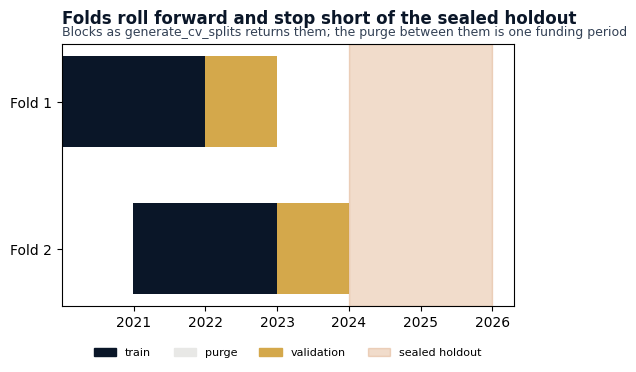

In [11]:
splits = sorted(
    generate_cv_splits(
        research, case_study_id=CASE_STUDY_ID, label_buffer=LABEL_BUFFER, date_col="timestamp"
    ),
    key=lambda split: split["train_start"],
)
for position, split in enumerate(splits):
    split["fold"] = position
last_val = max(split["val_end"] for split in splits)
assert len(splits) == SETUP["evaluation"]["n_splits"], "fold count differs from setup.yaml"
assert last_val < pd.Timestamp(HOLDOUT_START, tz="UTC"), "a fold reaches into the holdout"

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
fold_timeline(ax, splits, holdout=(HOLDOUT_START, HOLDOUT_END))
add_message_title(
    ax,
    "Folds roll forward and stop short of the sealed holdout",
    subtitle="Blocks as generate_cv_splits returns them; the purge between them is one funding period",
)
plt.show()

## E. Derived artifacts. Nothing: `setup.yaml::universe.symbols` fixes the contract list and the
loader carries no row before a listing, so no downstream file reads an eligibility table here.

## F. Findings vs `setup.yaml`. One row per knob: the evidence that motivates it, and what
would change it.

| Knob | Evidence | Revise it when |
|---|---|---|
| `universe.symbols`, `backtest.sweep.top_k_grid` | B.2 breadth against twice the largest top-k | breadth falls below the contracts a sleeve needs on both legs, as it does here at top-10 |
| `decision.cadence` | B.3 exceedance, B.4 persistence | moves stop clearing the round trip, or the premium decays inside one funding period |
| `costs.fee_schedule` | B.3 the two declared round trips | the venue changes a tier, or a contract moves between them |
| `evaluation.n_splits` | D.1 independent observations, D.2 boundaries | the folds no longer fit the development window |

In [12]:
print(
    f"universe.n_assets {SETUP['universe']['n_assets']}, breadth {breadth['n'].min()} to "
    f"{breadth['n'].max()}, under the floor of {BREADTH_FLOOR} on "
    f"{breadth.filter(pl.col('n') < BREADTH_FLOOR).height:,} of {len(breadth):,} timestamps\n"
    f"decision.cadence {SETUP['decision']['cadence']} | labels.primary {PRIMARY_LABEL}\n"
    f"evaluation.n_splits {SETUP['evaluation']['n_splits']}, generated {len(splits)}, last "
    f"validation ends {last_val.date()}, holdout untouched"
)

universe.n_assets 19, breadth 2 to 19, under the floor of 20 on 4,382 of 4,382 timestamps
decision.cadence 8_hour_funding_aligned | labels.primary fwd_ret_8h
evaluation.n_splits 2, generated 2, last validation ends 2023-12-31, holdout untouched


The declared universe holds 19 contracts. Breadth at a funding timestamp runs from 2 to 19 and
stays under the floor of 20 that the widest declared sleeve needs on all 4,382 of them, so the
top-10 grid entry cannot fill both legs anywhere in the development window. Two folds are
generated, the last validation ending 2023-12-31. An integrated autocorrelation of 37 funding
periods leaves at most 30 independent premium observations per contract a year, of 1,095.

## Key takeaways

1. **Count the panel at the timestamp the strategy acts on.** Members entering at their listing
   dates give breadth a history the declared sleeve has to fit inside at every timestamp.
2. **Compute a panel autocorrelation inside each entity, over unbroken stretches.** Stacking
   contracts measures where two of them meet; counting lags by row measures across the gaps.
3. **Turn persistence into an observation count before trusting a sample size.** Where the
   initial positive sequence runs past the lags you drew, that count is a ceiling, not a level.
4. **Separate the common level from the cross-sectional spread.** A ranking reads only what is
   left once the level both legs cancel comes out, and here the level is the larger part.

### Known limitations

- The contract list is fixed and was drawn knowing which perpetuals stayed listed, so it carries
  selection and delisting bias.
- Cost is the published fee alone; slippage and the entry spread need a notional and enter at the
  cost stage. Funding itself is a cash flow this strategy does not collect - labels and backtest
  measure the price move net of fees, and the premium enters only as a feature.

**Next**: labels at the declared horizons, built on this development window.